# **Logistic Regression**

**importing frameworks**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

**sigmoid function**

In [3]:
def sigmoid_func(x):
  return 1 / (1 + np.exp(x))

In [5]:
print(sigmoid_func(200))

1.3838965267367376e-87


*From above function we can see that the value will be on the range of 0 - 1*

**function to create random dataset using make_classification**

In [15]:
def generate_dataset():
  dataset = make_classification(n_samples = 30, n_features = 1, n_repeated = 0, n_redundant = 0,
                                shift = 30, scale= 10, n_classes = 2, n_clusters_per_class = 1, n_informative = 1,
                                class_sep = 1, random_state = 42)
  df = pd.DataFrame(dataset[0])
  df = pd.concat([(np.ceil(df)).astype(int), pd.DataFrame(dataset[1])],axis = 1)
  df.columns = ["GRE_Score","Admission"]
  return df

In [18]:
data = generate_dataset()
data.shape

(30, 2)

In [17]:
data.sample(5)

,GRE_Score,Admission
16,292,0
6,291,0
19,309,1
1,284,0
0,296,0


<Axes: xlabel='GRE_Score', ylabel='Admission'>

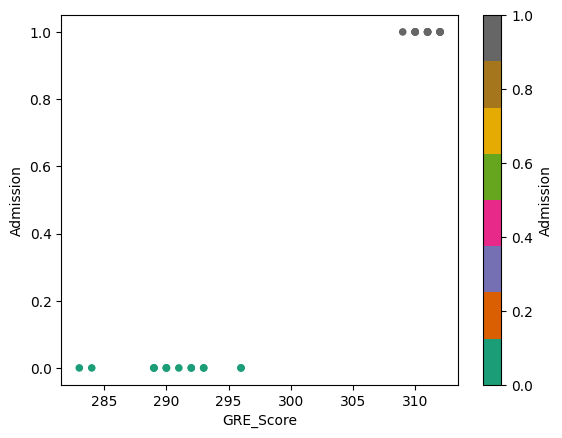

In [19]:
data.plot.scatter(x = "GRE_Score", y = "Admission",c = "Admission",cmap = "Dark2")

**performing linear regression**

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [24]:
linear_model = LinearRegression()
scale = StandardScaler()

In [50]:
map_color = np.array(["r","b"])
x = data[["GRE_Score"]].to_numpy()
y = data[["Admission"]].to_numpy()

In [49]:
X = scale.fit_transform(x)

In [30]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [35]:
linear_model.fit(X_train,y_train)

LinearRegression()

In [36]:
y_pred = linear_model.predict(X_test)

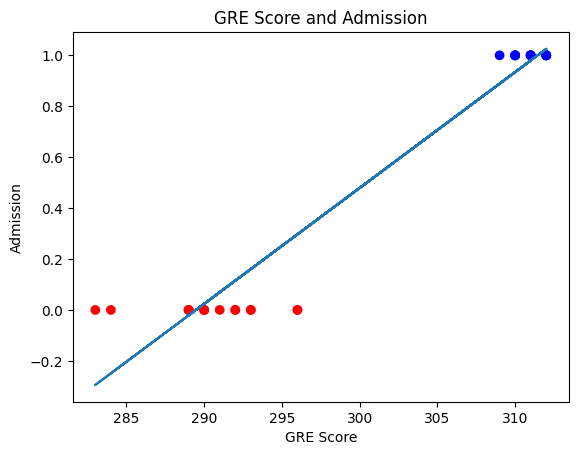

In [39]:
plt.scatter(x,y,c=map_color[y.ravel()])
plt.plot(x,linear_model.predict(x))
plt.title("GRE Score and Admission")
plt.xlabel("GRE Score")
plt.ylabel("Admission")
plt.show()

# **From here Logistic Regression starts**

In [51]:
linear_model.fit(x,y)

LinearRegression()

In [52]:
y_hat = linear_model.predict(x)

In [53]:
prob_y = sigmoid_func(y_hat)

In [54]:
threshold = 0.6

result = prob_y > threshold
result.astype(int).flatten()

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0])

# **New Example of Logistic Regression**

- **predicting if a person survived or not from Titanic Dataset**

In [56]:
from google.colab import drive
drive.mount("/content/Drive")

Mounted at /content/Drive


In [116]:
titanic_df = pd.read_csv("/content/Drive/MyDrive/dsml/titanic.csv")

In [117]:
titanic_df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
178,0,2,male,30.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
231,0,3,male,29.0,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True
20,0,2,male,35.0,0,0,26.0000,S,Second,man,True,NaN,Southampton,no,True
362,0,3,female,45.0,0,1,14.4542,C,Third,woman,False,NaN,Cherbourg,no,False
104,0,3,male,37.0,2,0,7.9250,S,Third,man,True,NaN,Southampton,no,False


In [118]:
datas = titanic_df[["pclass","sex","age","fare","embarked","survived"]]

In [119]:
datas.isna().sum()

,0
pclass,0
sex,0
age,177
fare,0
embarked,2
survived,0


In [120]:
datas.sample(5)

,pclass,sex,age,fare,embarked,survived
756,3,male,28.0,7.7958,S,0
569,3,male,32.0,7.8542,S,1
594,2,male,37.0,26.0000,S,0
336,1,male,29.0,66.6000,S,0
12,3,male,20.0,8.0500,S,0


In [121]:
datas

,pclass,sex,age,fare,embarked,survived
0,3,male,22.0,7.2500,S,0
1,1,female,38.0,71.2833,C,1
2,3,female,26.0,7.9250,S,1
3,1,female,35.0,53.1000,S,1
4,3,male,35.0,8.0500,S,0
...,...,...,...,...,...,...
886,2,male,27.0,13.0000,S,0
887,1,female,19.0,30.0000,S,1
888,3,female,NaN,23.4500,S,0
889,1,male,26.0,30.0000,C,1


In [122]:
datas["sex"] = datas["sex"].fillna(datas["sex"].mode()[0])
datas["embarked"] = datas["embarked"].fillna(datas["embarked"].mode()[0])

/tmp/ipykernel_694/3147997381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datas["sex"] = datas["sex"].fillna(datas["sex"].mode()[0])
/tmp/ipykernel_694/3147997381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datas["embarked"] = datas["embarked"].fillna(datas["embarked"].mode()[0])


In [127]:
datas = pd.get_dummies(datas,columns = ["sex","embarked"],drop_first = True)

In [130]:
datas.sample(5)

,pclass,age,fare,survived,sex_male,embarked_Q,embarked_S,embakred_S
731,3,11.0,18.7875,0,1,0,False,0
504,1,16.0,86.5000,1,0,0,True,1
277,2,NaN,0.0000,0,1,0,True,1
42,3,NaN,7.8958,0,1,0,False,0
859,3,NaN,7.2292,0,1,0,False,0


In [154]:
datas[["sex_male","embarked_Q","embakred_S"]] = datas[["sex_male","embarked_Q","embarked_S"]].astype(int)
datas.drop(columns = ["embarked_S"],axis = 1)

,pclass,age,fare,survived,sex_male,embarked_Q,embakred_S
0,3,22.000000,7.2500,0,1,0,1
1,1,38.000000,71.2833,1,0,0,0
2,3,26.000000,7.9250,1,0,0,1
3,1,35.000000,53.1000,1,0,0,1
4,3,35.000000,8.0500,0,1,0,1
...,...,...,...,...,...,...,...
886,2,27.000000,13.0000,0,1,0,1
887,1,19.000000,30.0000,1,0,0,1
888,3,29.699118,23.4500,0,0,0,1
889,1,26.000000,30.0000,1,1,0,0


In [137]:
datas["age"] = datas["age"].fillna(datas["age"].mean())

In [138]:
X = datas[["pclass","fare","age","sex_male","embarked_Q","embarked_S"]].to_numpy()
y = datas[["survived"]].to_numpy()

In [139]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [140]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [141]:
logistic_model = LogisticRegression()

In [142]:
logistic_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [143]:
y_pred = logistic_model.predict(X_test)

In [150]:
from sklearn.metrics import r2_score, accuracy_score

In [151]:
r2_score = r2_score(y_test,y_pred)
accuracy = accuracy_score(y_test,y_pred)

In [153]:
print("R2 Score:",r2_score)
print("Accuracy Score:",accuracy * 100)

R2 Score: 0.17065637065637063
Accuracy Score: 79.88826815642457


In [165]:
X.shape

(891, 6)

In [166]:
y.shape

(891, 1)

**scatter plot of survived on the basis of PClass**

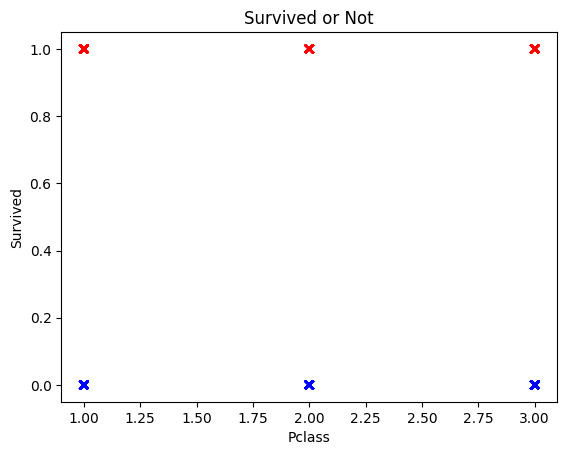

In [174]:
plt.scatter(X[:,0],y.ravel(),c = y.ravel(),cmap = "bwr",marker = "x")
plt.title("Survived or Not")
plt.xlabel("Pclass")
plt.ylabel("Survived")
plt.show()

**scatter plot of survived on the basis of gender**

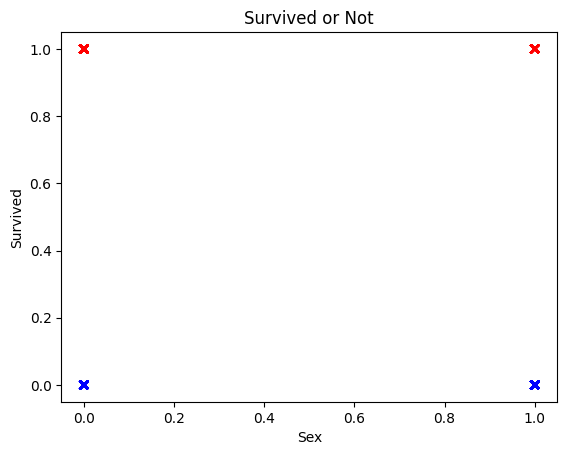

In [175]:
plt.scatter(X[:,3],y.ravel(),c = y.ravel(),cmap = "bwr",marker = "x")
plt.title("Survived or Not")
plt.xlabel("Sex")
plt.ylabel("Survived")
plt.show()

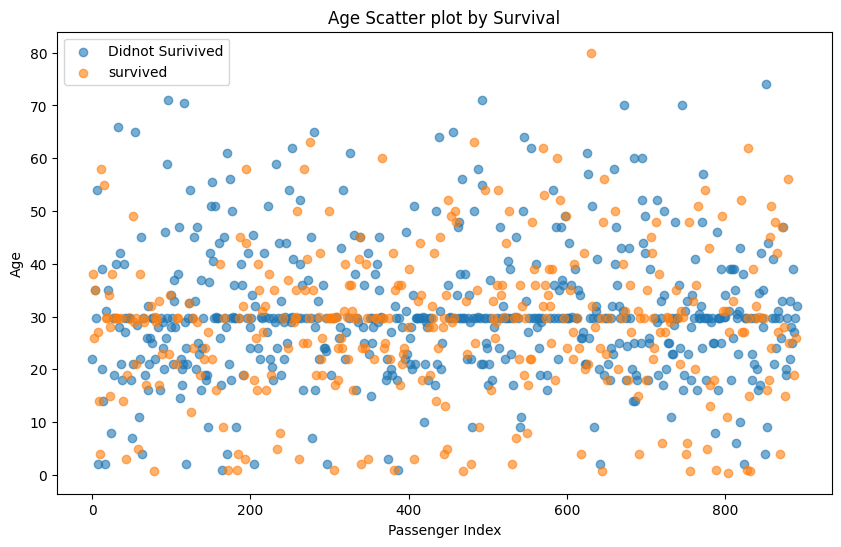

In [179]:
plt.figure(figsize = (10,6))
plt.scatter(
    datas[datas["survived"] == 0].index,
    datas[datas["survived"] == 0]["age"],
    alpha = 0.6,
    label = "Didnot Surivived"
)

plt.scatter(
    datas[datas["survived"] == 1].index,
    datas[datas["survived"] == 1]["age"],
    alpha = 0.6,
    label = "survived"
)
plt.title("Age Scatter plot by Survival")
plt.xlabel("Passenger Index")
plt.ylabel("Age")
plt.legend()
plt.show()